In [1]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('netflix_titles.csv')


In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [7]:
df.fillna("Unknown", inplace=True)

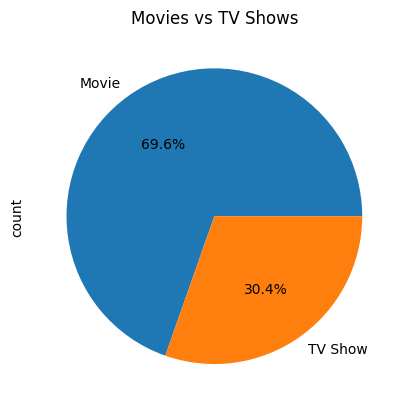

In [8]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()

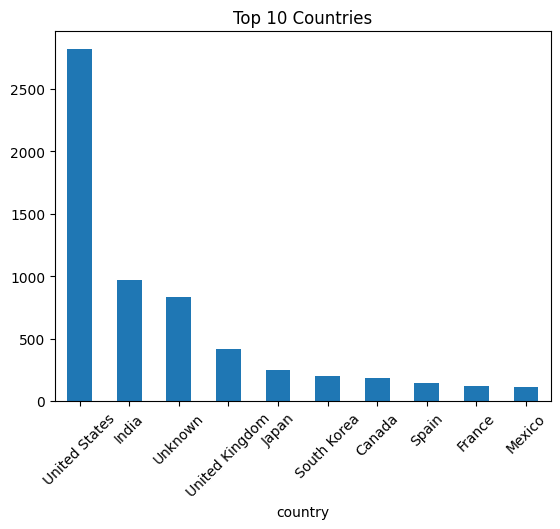

In [9]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.xticks(rotation=45)
plt.show()

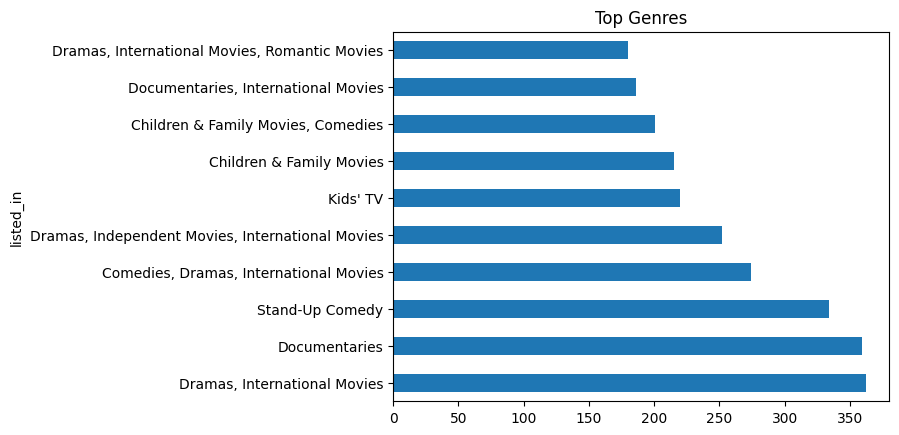

In [10]:
df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.title("Top Genres")
plt.show()

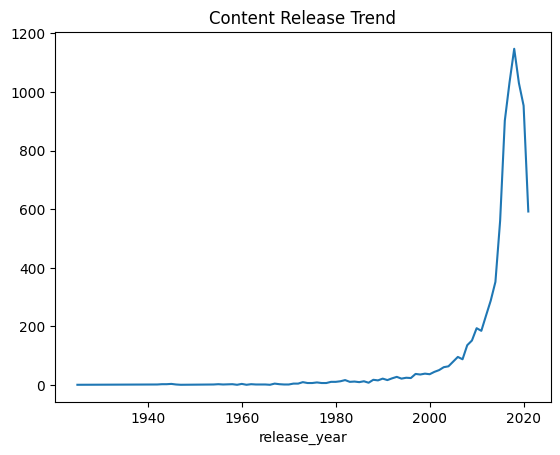

In [11]:
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title("Content Release Trend")
plt.show()

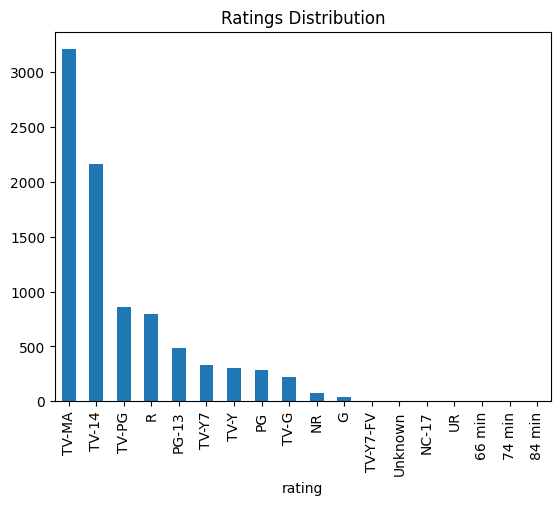

In [12]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Ratings Distribution")
plt.show()

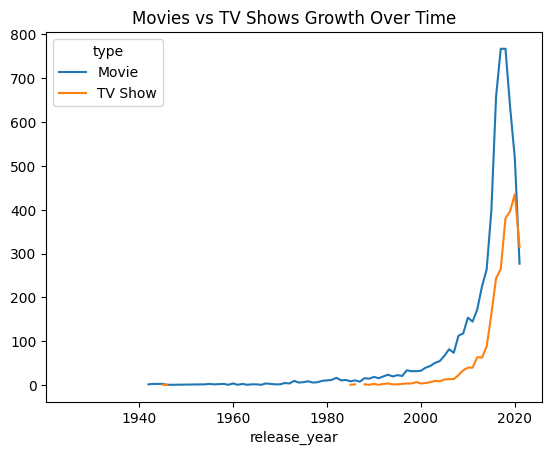

In [13]:
type_year = df.groupby(['release_year','type']).size().unstack()

type_year.plot()
plt.title("Movies vs TV Shows Growth Over Time")
plt.show()

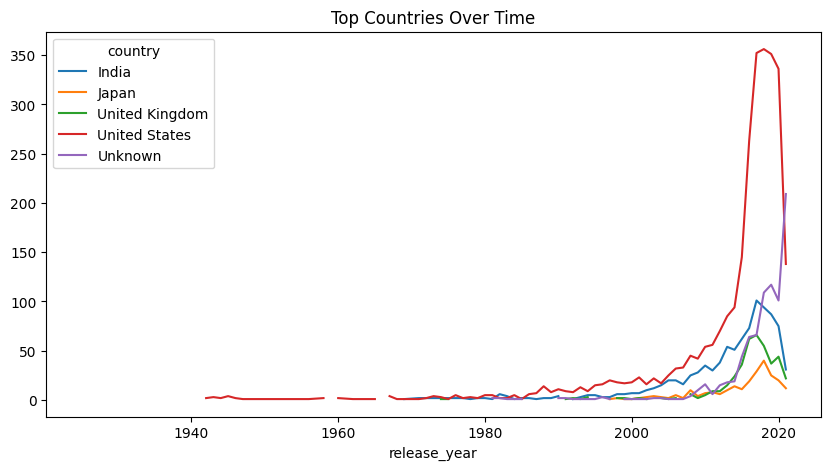

In [14]:
top_countries = df['country'].value_counts().head(5).index
filtered = df[df['country'].isin(top_countries)]

country_year = filtered.groupby(['release_year','country']).size().unstack()
country_year.plot(figsize=(10,5))
plt.title("Top Countries Over Time")
plt.show()

In [15]:
from collections import Counter

genres = df['listed_in'].str.split(', ')
all_genres = [g for sublist in genres for g in sublist]

Counter(all_genres).most_common(10)

[('International Movies', 2752),
 ('Dramas', 2427),
 ('Comedies', 1674),
 ('International TV Shows', 1351),
 ('Documentaries', 869),
 ('Action & Adventure', 859),
 ('TV Dramas', 763),
 ('Independent Movies', 756),
 ('Children & Family Movies', 641),
 ('Romantic Movies', 616)]

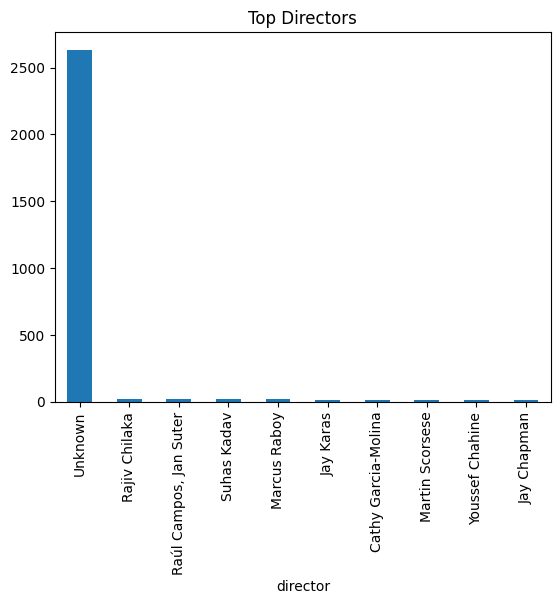

In [17]:
top_directors = df['director'].value_counts().head(10)
top_directors.plot(kind='bar')
plt.title("Top Directors")
plt.show()

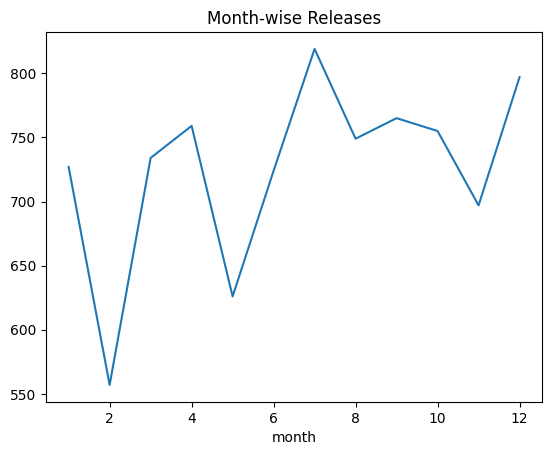

In [18]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['month'] = df['date_added'].dt.month

df['month'].value_counts().sort_index().plot()
plt.title("Month-wise Releases")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

X = df['description']
y = df['type']

cv = CountVectorizer(stop_words='english')
X = cv.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.746311010215664
